# Vector Spaces in DSP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

## "The Axiom Verifier": Linearity and Closure of signal spaces

### Signal Superposition

Consider $x[n]$ (e.g., a sine wave) and $y[n]$ (e.g., noise), where both $x[n]$ and $y[n] \in \mathbb{R}^N$ with $N = 1000$.

Use the adjustable sliders for $\alpha$ and $\beta$ to observe the resulting vector $z[n] = \alpha x[n] + \beta y[n]$. 

In [4]:
# Sine wave
fs = 1000  # Sampling frequency
f = 5      # Frequency of the sine wave
t = np.arange(0, 1, 1/fs)  # Time vector
x = np.sin(2 * np.pi * f * t)  # Sine wave signal

# Noise signal
np.random.seed(0)  # For reproducibility
y = np.random.normal(0, 0.5, len(t))  # Gaussian noise signal

def plot_superposition(alpha=1.0, beta=1.0):
    """Interactive plot of signal superposition with adjustable coefficients."""
    # Resulting signal
    z = alpha * x + beta * y
    
    plt.figure(figsize=(10, 6))
    plt.plot(t, z, label=f'z[n] = {alpha:.1f}x[n] + {beta:.1f}y[n]', color='purple', linewidth=2)
    plt.plot(t, y, label='y[n] (Noise)', linestyle='--', alpha=0.6)
    plt.plot(t, x, label='x[n] (Sine Wave)', linestyle='--', alpha=1)
    plt.title('Signal Superposition')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-3, 3)  # Fixed y-axis for better comparison
    plt.show()

# Create interactive sliders
interact(plot_superposition, 
         alpha=FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description='α:'),
         beta=FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description='β:'))

interactive(children=(FloatSlider(value=1.0, description='α:', max=2.0, min=-2.0), FloatSlider(value=1.0, desc…

<function __main__.plot_superposition(alpha=1.0, beta=1.0)>

### Verification Logic

Define the "set" of signals and checks if they are closed under addition. For instance, if the set is "all signals with values between 0 and 1," does it form a vector space? (Hint: No, because scaling by -1 leaves the set).

In [5]:
def is_closed_under_addition(signal_set, signal1, signal2):
    """Check if the sum of two signals in the set remains in the set."""
    summed_signal = signal1 + signal2
    return np.all((summed_signal >= signal_set[0]) & (summed_signal <= signal_set[1]))

# Define the set of signals with values between 0 and 1
signal_set = (0, 1)
signal1 = np.random.uniform(0, 1, 100)
signal2 = np.random.uniform(0, 1, 100)
closure_result = is_closed_under_addition(signal_set, signal1, signal2)
print(f"Is the set of signals with values between {signal_set[0]} and {signal_set[1]} closed under addition? {closure_result}")


Is the set of signals with values between 0 and 1 closed under addition? False


### The Zero Signal

Plot the additive identity for various spaces: a vector of zeros for $\mathbb{C}^N$ and a function $x(t) = 0$ for $L^2(\mathbb{R})$.

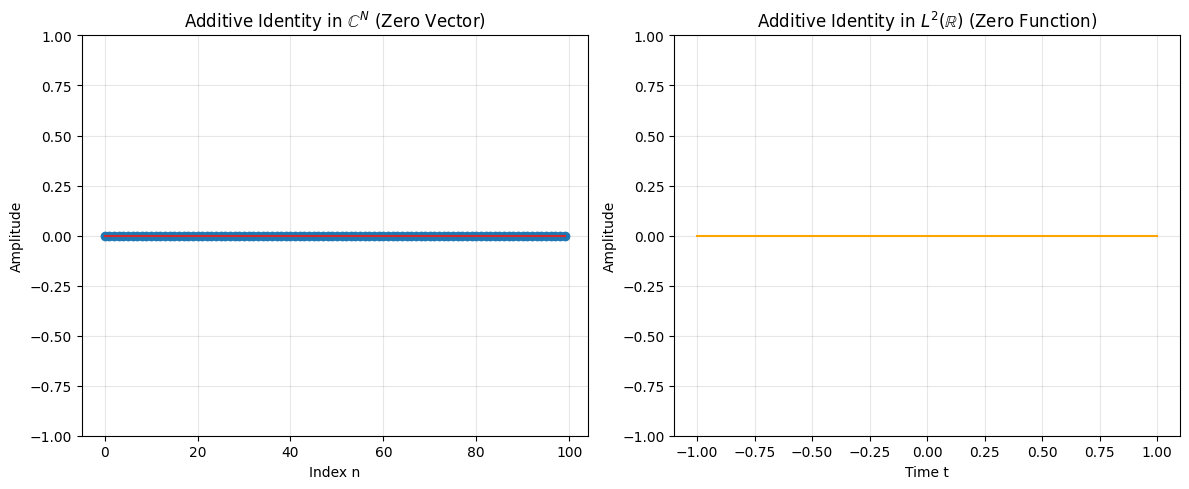

In [6]:
# Discrete space: C^N
N = 100
zero_vector = np.zeros(N)

plt.figure(figsize=(12, 5))

# Plot for C^N
plt.subplot(1, 2, 1)
plt.stem(zero_vector)
plt.title(r'Additive Identity in $\mathbb{C}^N$ (Zero Vector)')
plt.xlabel('Index n')
plt.ylabel('Amplitude')
plt.ylim(-1, 1)
plt.grid(alpha=0.3)

# Continuous space: L^2(R)
t_cont = np.linspace(-1, 1, 500)
zero_function = np.zeros_like(t_cont)

# Plot for L^2(R)
plt.subplot(1, 2, 2)
plt.plot(t_cont, zero_function, color='orange')
plt.title(r'Additive Identity in $L^2(\mathbb{R})$ (Zero Function)')
plt.xlabel('Time t')
plt.ylabel('Amplitude')
plt.ylim(-1, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## The Subspace Navigator

Now we will focus on the concept of **Linear Combinations** and **Geometric Translation**.

### Subspace vs. Affine

Consider a plane $S$ passing through $(0,0,0)$. This is a subspace. Use a slider to see the effect of a translation vector $x$. Watch the plane $S$ shift into an affine subspace $T = x + S$.

In [ ]:
def plot_subspace_affine(translation_x=0.0, translation_y=0.0, translation_z=0.0):
    """Plot the subspace and its affine translation."""
    # Define the subspace S (a plane)
    x = np.linspace(-5, 5, 10)
    y = np.linspace(-5, 5, 10)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)  # Plane at z=0

    # Define the translation vector
    translation_vector = np.array(
        [translation_x, translation_y, translation_z])

    # Plotting
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot subspace S
    ax.plot_surface(X, Y, Z, alpha=0.5, color='blue', label='Subspace S')

    # Plot affine subspace T
    Z_affine = Z + translation_vector[2]  # Shift in z-direction
    ax.plot_surface(X + translation_vector[0], Y + translation_vector[1],
                    Z_affine, alpha=0.5, color='orange', label='Affine Subspace T')

    # Plot translation vector
    ax.quiver(0, 0, 0, translation_vector[0], translation_vector[1],
              translation_vector[2], color='red', linewidth=2, label='Translation Vector')
    
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_zlim(-10, 10)

    ax.set_title('Subspace S and Affine Subspace T')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('Z-axis')
    ax.legend()
    plt.show()


# Create interactive sliders for translation
interact(plot_subspace_affine,
         translation_x=FloatSlider(
             value=0.0, min=-5.0, max=5.0, step=0.1, description='Translation X:'),
         translation_y=FloatSlider(
             value=0.0, min=-5.0, max=5.0, step=0.1, description='Translation Y:'),
         translation_z=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description='Translation Z:'))

interactive(children=(FloatSlider(value=0.0, description='Translation X:', max=5.0, min=-5.0), FloatSlider(val…

<function __main__.plot_subspace_affine(translation_x=0.0, translation_y=0.0, translation_z=0.0)>





*   **Visualization 2: Signal Synthesis.** Use the **Haar wavelet** basis. Show that by taking different linear combinations of specific wavelet "shapes" (basis vectors), the resulting signal stays within the **span** of those vectors, effectively navigating within a specific subspace of $L^2$.
*   **Constraint Checking:** Provide a tool where the user inputs a "rule" (e.g., "signals where the first sample is twice the second"). The notebook will then test if this set is closed under addition and scaling to determine if it is a subspace.

---

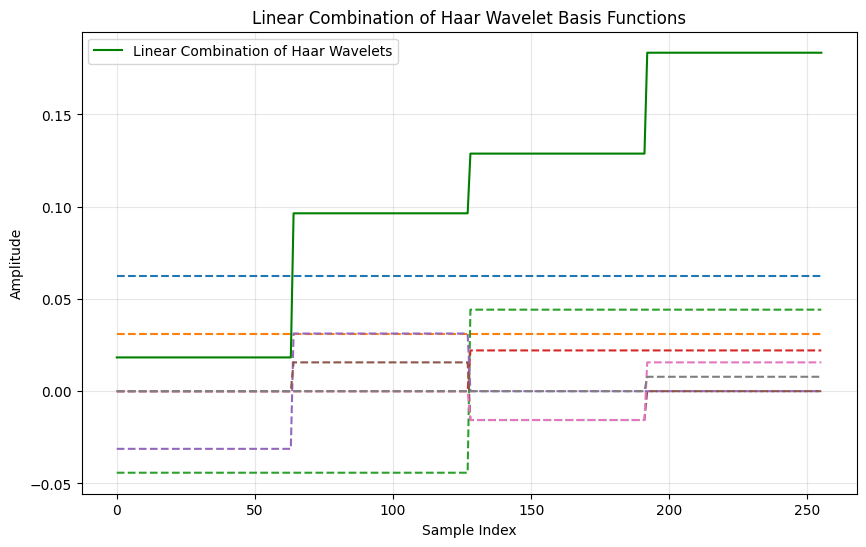

In [ ]:
# Use the **Haar wavelet** basis. Show that by taking different linear combinations of specific wavelet "shapes" (basis vectors), 
# the resulting signal stays within the **span** of those vectors, effectively navigating within a specific subspace of $L^2$.


def haar_wavelet(n, N):
    """Generate the n-th Haar wavelet basis function of length N."""
    if n == 0:
        return np.ones(N) / np.sqrt(N)  # Scaling function (constant)
    
    # Determine the level and position of the wavelet
    level = int(np.floor(np.log2(n)))
    position = n - 2**level
    
    # Calculate the support of the wavelet
    start = position * (N // 2**level)
    end = (position + 1) * (N // 2**level)
    
    # Create the wavelet function
    wavelet = np.zeros(N)
    wavelet[start:end] = 1 / np.sqrt(N // 2**level)  # Positive part
    wavelet[end:end + (N // 2**level)] = -1 / np.sqrt(N // 2**level)  # Negative part
    
    return wavelet

# Generate the first few Haar wavelet basis functions
N = 256  # Length of the signal
basis_functions = [haar_wavelet(n, N) for n in range(8)]

# Create linear combinations of the basis functions
coefficients = [1, 0.5, -0.5, 0.25, -0.25, 0.125, -0.125, 0.0625]
scaled_basis_functions = [c * b for c, b in zip(coefficients, basis_functions)]
linear_combination = sum(scaled_basis_functions)

# Plot the linear combination of Haar wavelet basis functions
plt.figure(figsize=(10, 6))
plt.plot(np.array(scaled_basis_functions).T, linestyle='--')
plt.plot(linear_combination, color='green', label='Linear Combination of Haar Wavelets')
plt.title('Linear Combination of Haar Wavelet Basis Functions')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## The Geometry of Independence

Previously we defined signals as vectors in $\mathbb{R}^N$ or $\mathbb{C}^N$. Now, we will explore the concept of vector spaces using two-dimensional vectors. Assume two vectors $x_1, x_2 \in \mathbb{R}^2$ defined as:

$$
x_1 = 
\begin{bmatrix}
1 \\ 
2
\end{bmatrix},
\quad x_2 =
\begin{bmatrix}
2 \\ 
1
\end{bmatrix}
$$

First, lets show that $x_1$ and $x_2$ are linearly independent given the following expression:

$$
\alpha x_1 + \beta x_2 = 0.
$$

$$
\alpha
\begin{bmatrix}
1 \\ 
2
\end{bmatrix} + 
\beta
\begin{bmatrix}
2 \\ 
1
\end{bmatrix} = 
\begin{bmatrix}
0 \\ 
0
\end{bmatrix},
$$

which gives

$$
\begin{align*}
\alpha + 2\beta &= 0\\ 
2\alpha + \beta &= 0
\end{align*}
$$


Solving for $\alpha$ and $\beta$, the only condition for the equations above to be held is that $\alpha = 0$ and $\beta = 0$ so we can say that the vectors are linearly independent.

Given that $\alpha,\beta \in \mathbb{R}$ and $x_1, x_2$ are linearly independent, the linear combination $\alpha x_1 + \beta x_2$ gives all vectors in the 2D space (infinite plane). We can also say that the basis $x_1$, $x_2$ is a linearly independent spanning set over $\mathbb{R}^2$.

Now we will explore the set spanned by all linear combinations of the form $\alpha x_1 + \beta x_2$ with the following restrictions:

### $\alpha, \beta \in \mathbb{R}$: 

In this case there are no restrictions for $\alpha$ and $\beta$.

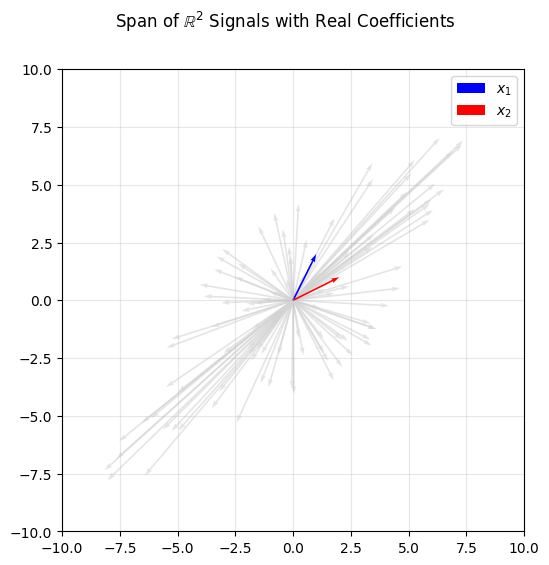

In [42]:
x1 = np.array([1, 2])
x2 = np.array([2, 1])

alpha = np.random.uniform(-3, 3, 100)
beta = np.random.uniform(-3, 3, 100)
n = len(alpha)

def plot_span_real_coefficients():
    """Plot the span of R^2 signals with real coefficients."""
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(n):
        z = alpha[i] * x1 + beta[i] * x2
        ax.quiver(
            0, 0,
            z[0], z[1],
            units = 'xy',
            scale = 1,
            width = 0.07,
            color='lightgray',
            alpha=0.6,
        )

    ax.quiver(0, 0, x1[0], x1[1], units = 'xy', scale = 1, width = 0.07, color='blue', label='$x_1$')
    ax.quiver(0, 0, x2[0], x2[1], units = 'xy', scale = 1, width = 0.07, color='red', label='$x_2$')

    ax.set_aspect('equal')
    ax.set_ylim(-10, 10)
    ax.set_xlim(-10, 10)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.suptitle(r'Span of $\mathbb{R}^2$ Signals with Real Coefficients')


plot_span_real_coefficients()
plt.show()

### $\alpha,\beta \in \mathbb{R}$: $\alpha + \beta = 1$

In this case, the linear combinations of $x_1$ and $x_2$ are restricted to those where the sum of the coefficients equals 1. This means that we can express $\beta$ in terms of $\alpha$ as $\beta = 1 - \alpha$.

$$
\alpha
\begin{bmatrix}
1 \\ 
2
\end{bmatrix} + 
(1- \alpha)
\begin{bmatrix}
2 \\ 
1
\end{bmatrix} = 
\begin{bmatrix}
a \\ 
b
\end{bmatrix},
$$

which gives

$$
\begin{align*}
\alpha + 2(1- \alpha) &= a\\ 
2\alpha + (1- \alpha) &= b
\end{align*}
$$

Then,

$$
\begin{align*}
2 - \alpha &= a\\ 
\alpha + 1 &= b
\end{align*}
$$

From the secon equeation we get $\alpha = b - 1$, and replacing in the first equation, we obtain:

$$
2 - b + 1 = a
$$

Reordering the terms we obtain the equation of a line 

$$
b = 3 - a
$$ 

which is the spanning set when $\alpha + \beta = 1$.

This constraint means that the resulting vectors will lie on a line. Geometrically, this represents all points that can be expressed as a weighted average of $x_1$ and $x_2$, effectively forming a line in the 2D plane. This line is an affine subspace of $\mathbb{R}^2$, not a vector subspace, because it does not include the zero vector unless the line passes through the origin.


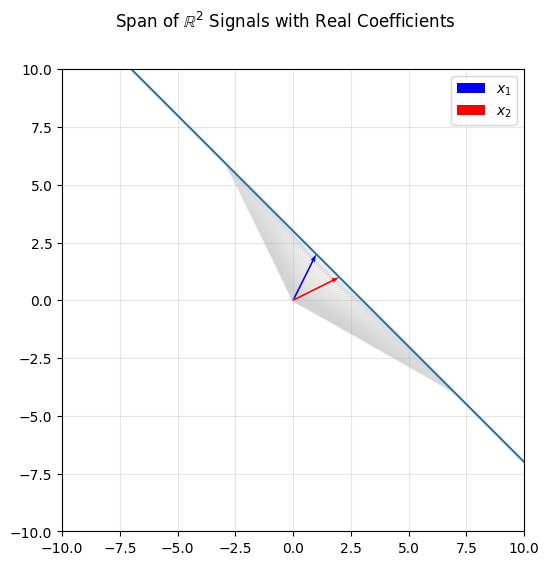

In [43]:
alpha = np.arange(-5, 5, 0.1)
beta = 1 - alpha
n = len(alpha)

plot_span_real_coefficients()

# Plot the line defined by α + β = 1
ax = plt.gca()
a = np.arange(-10, 15)
b = 3 - a
ax.plot(a, b)
plt.show()

### $\alpha + \beta = 1$, $0\leq \alpha \leq 1$, and $0\leq \beta \leq 1$

With the restrictions $\alpha + \beta = 1$, $0\leq \alpha \leq 1$ and $0\leq \beta \leq 1$ the problem can be formulatad as:

$$
\alpha
\begin{bmatrix}
1 \\ 
2
\end{bmatrix} + 
(1- \alpha)
\begin{bmatrix}
2 \\ 
1
\end{bmatrix} = 
\begin{bmatrix}
a \\ 
b
\end{bmatrix},
$$

which gives

$$
\begin{align*}
\alpha + 2(1- \alpha) &= a\\ 
2\alpha + (1- \alpha) &= b
\end{align*}
$$

Then,

$$
\begin{align*}
2 - \alpha &= a\\ 
\alpha + 1 &= b
\end{align*}
$$

From the second equation above and from the fact that $0\leq \alpha \leq 1$, we can deduce that $1 \leq b \leq 2$, given that adding 1 to any number in the interval $[0, 1]$ would yield a number in the interval $[1, 2]$. A similar analysis is done for the first equation, given that the minus sign flips the interval of $\alpha$. Then, if we add 2 to any number in the interval $[-1, 0]$, we obtain a number in the interval $[1, 2]$. Thus $1 \leq a \leq 2$

Following the same procedure of the previos problem, we obtain the equation of a line $b = 3-a$ bounded with $a, b \in [1,2]$ which gives a line segmen as the spanning set when $\alpha + \beta = 1$, $0\leq \alpha \leq 1$ and $0\leq \beta \leq 1$.

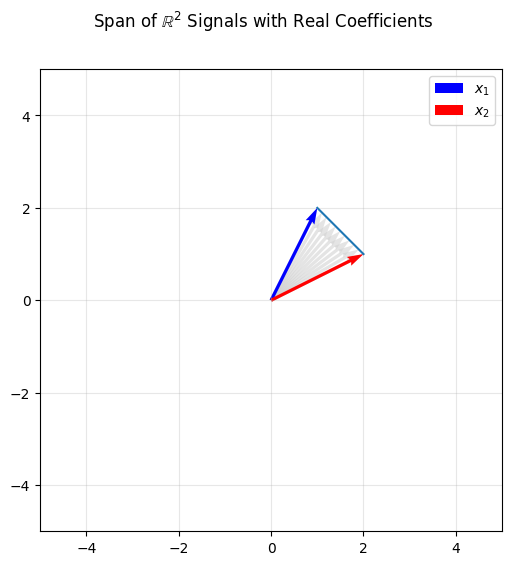

In [45]:
alpha = np.arange(0, 1.1, 0.1)
beta = 1 - alpha
n = len(alpha)

plot_span_real_coefficients()

# Plot the line defined by α + β = 1
ax = plt.gca()
a = np.arange(1, 2.1, 0.1)
b = 3 - a
ax.plot(a, b)
ax.set_ylim(-5, 5)
ax.set_xlim(-5, 5)
plt.show()





### Proposing Interactive Jupyter Notebook 3: "The Geometry of Independence"

*   **Visualization 1: The Zero-Vector Game.** In a 3D coordinate system, provide the user with two fixed vectors. Allow the user to drag a third vector. Highlight in real-time if the third vector lies in the **span** of the first two. If it does, find the scalars $\alpha_1, \alpha_2$ such that $\alpha_1 \phi_1 + \alpha_2 \phi_2 = \phi_3$, demonstrating dependency.
*   **Visualization 2: Redundant Fourier Bases.** Take a 4-point signal. Use the 4 standard DFT basis vectors and then add a 5th "random" vector. Show how the same signal can now be represented by **infinitely many different sets of coefficients**, illustrating the loss of uniqueness in redundant frames.
*   **Thought Experiment:** If you have a 3D space, can you find 4 vectors that *don't* span it? Can you find 2 vectors that *do* span it?

---